In [ ]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns

import os
import sys
SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(SRC_PATH)

from src.common.utils import load_pres
from src.common.stopwords import STOPWORDS
from src.presidents.transformer import TextPreprocessor
from src.common.visualization import plot_class_wordclouds

%load_ext autoreload
%autoreload 2

<Axes: ylabel='count'>

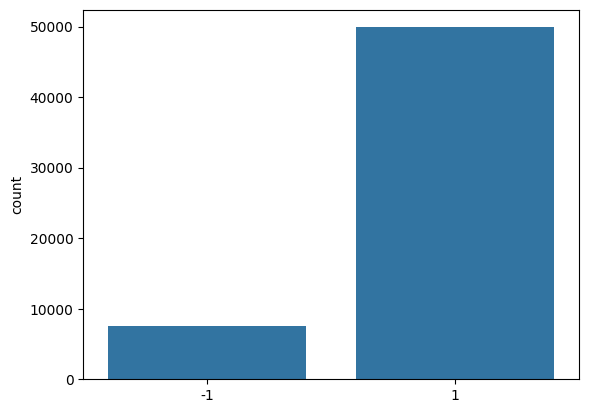

In [ ]:
fname = "../Dataset/presidents.utf8"
texts, classes = load_pres(fname)
sns.countplot(x=classes)

In [ ]:
text_preprocessor = TextPreprocessor(stem=False, lemmatize=True, stopwords=STOPWORDS["french"]).fit(texts)
texts_cleaned = text_preprocessor.transform([text for text in texts])

Length of vocab: 23214


<Axes: ylabel='Count'>

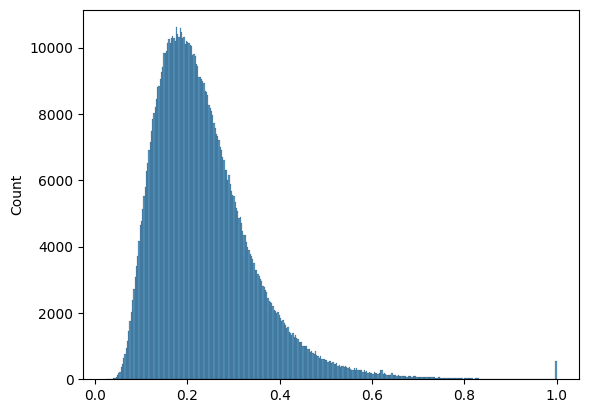

In [ ]:
tfidf_vectorizer = TfidfVectorizer(min_df=5, max_df=0.5, ngram_range=(1, 2))
matrix = tfidf_vectorizer.fit_transform(texts_cleaned)
vocab = tfidf_vectorizer.get_feature_names_out()

print("Vocab length:", len(vocab))
sns.histplot(matrix.data)

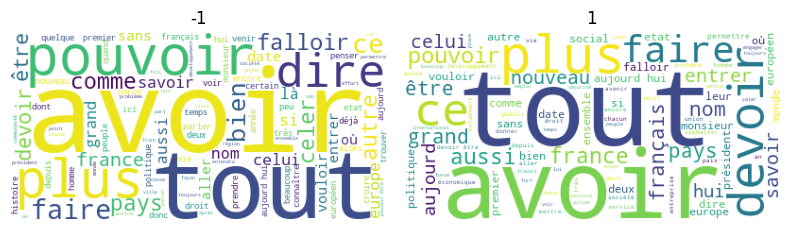

In [ ]:
vectorizer = CountVectorizer(ngram_range=(1, 2), vocabulary=vocab)
fig=plot_class_wordclouds(texts_cleaned, classes, vectorizer)

In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(texts_cleaned, classes, random_state=42)

In [ ]:
pipeline = Pipeline([
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.50, max_features=5000)),
    ("classifier", MultinomialNB()) 
])

# Cross validation
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

0.8876968092517765
              precision    recall  f1-score   support

          -1       0.57      0.47      0.52      1823
           1       0.93      0.95      0.94     12531

    accuracy                           0.89     14354
   macro avg       0.75      0.71      0.73     14354
weighted avg       0.88      0.89      0.88     14354



In [ ]:
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(min_df=5, max_df=0.50, max_features=20000)),
    ("classifier", LogisticRegression(class_weight="balanced")) 
])

# # Cross validation
scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Scores : [0.80608453 0.81119368 0.81084533 0.81339991 0.80896528], mean score : 0.8100977465229209
0.8109237843109934
              precision    recall  f1-score   support

          -1       0.37      0.72      0.49      1823
           1       0.95      0.82      0.88     12531

    accuracy                           0.81     14354
   macro avg       0.66      0.77      0.69     14354
weighted avg       0.88      0.81      0.83     14354

